# Regression

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# load the training dataset
df = pd.read_csv('daily-bike-share.csv')
# df = pd.read_csv('/content/sample_data/daily-bike-share.csv') # upload CSV file in Colab,

print(df.head())

   day  mnth  year  season  holiday  weekday  workingday  weathersit  \
0    1     1  2011       1        0        6           0           2   
1    2     1  2011       1        0        0           0           2   
2    3     1  2011       1        0        1           1           1   
3    4     1  2011       1        0        2           1           1   
4    5     1  2011       1        0        3           1           1   

        temp     atemp      hum  windspeed  rentals  
0  14.110847  18.18125  80.5833  10.749882      331  
1  14.902598  17.68695  69.6087  16.652113      131  
2   8.050924   9.47025  43.7273  16.636703      120  
3   8.200000  10.60610  59.0435  10.739832      108  
4   9.305237  11.46350  43.6957  12.522300       82  


Because we have to repair the datatypes for both frames and we also want to learn something about programming as a side effect, we write a function for this task. It takes the dataframe, converts the variable "date" into datetime-format, all the categorial data into 'category' respectively 'bool'-format, gives meaningful names to all categories and returns a repaired frame.

In [11]:
# Fixing the datatypes 
df.loc[:,'season':'mnth'] = df.loc[:,'season':'mnth'].astype('category')
df[['holiday','workingday']] = df[['holiday','workingday']].astype('bool')
df[['weekday','weathersit']] = df[['weekday','weathersit']].astype('category')

# Get Meaningful Names for the categorial Variables
mapping_season = {1:"1_Winter", 2:"2_Spring", 3:"3_Summer", 4:"4_Fall" }
mapping_weekdays = {0:"Sunday", 1:"Monday", 2:"Tuesday", 3:"Wednesday", 
                    4:"Thursday", 5:"Friday", 6:"Saturday"}
mapping_weather = {1:"good", 2:"medium", 3:"poor", 4:"very_poor" }

df["season"] = df.season.map(mapping_season)
df["weekday"] = df.weekday.map(mapping_weekdays)
df["weathersit"] = df.weathersit.map(mapping_weather)

In [12]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   day         731 non-null    int64   
 1   mnth        731 non-null    int64   
 2   year        731 non-null    int64   
 3   season      731 non-null    object  
 4   holiday     731 non-null    bool    
 5   weekday     731 non-null    category
 6   workingday  731 non-null    bool    
 7   weathersit  731 non-null    category
 8   temp        731 non-null    float64 
 9   atemp       731 non-null    float64 
 10  hum         731 non-null    float64 
 11  windspeed   731 non-null    float64 
 12  rentals     731 non-null    int64   
dtypes: bool(2), category(2), float64(4), int64(4), object(1)
memory usage: 54.9+ KB
None


In [13]:
print(df.head(10))

   day  mnth  year    season  holiday    weekday  workingday weathersit  \
0    1     1  2011  1_Winter    False   Saturday       False     medium   
1    2     1  2011  1_Winter    False     Sunday       False     medium   
2    3     1  2011  1_Winter    False     Monday        True       good   
3    4     1  2011  1_Winter    False    Tuesday        True       good   
4    5     1  2011  1_Winter    False  Wednesday        True       good   
5    6     1  2011  1_Winter    False   Thursday        True       good   
6    7     1  2011  1_Winter    False     Friday        True     medium   
7    8     1  2011  1_Winter    False   Saturday       False     medium   
8    9     1  2011  1_Winter    False     Sunday       False       good   
9   10     1  2011  1_Winter    False     Monday        True       good   

        temp     atemp      hum  windspeed  rentals  
0  14.110847  18.18125  80.5833  10.749882      331  
1  14.902598  17.68695  69.6087  16.652113      131  
2   8.050924

## 4 EDA (DONE IN SEPERATE NOTEBOOK)

## 5. Data cleaning and feature engg.

In [14]:
# Re-normalize using the known max values
df['temp'] = df['temp'] / 41
df['atemp'] = df['atemp'] / 50
df['hum'] = df['hum'] / 100
df['windspeed'] = df['windspeed'] / 67

In [15]:
df.isnull().sum() # no missing values

day           0
mnth          0
year          0
season        0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
rentals       0
dtype: int64

## 6. Data split

Now that we've explored the data, it's time to use it to train a regression model that uses the features we've identified as potentially predictive to predict the **rentals** label.  The first thing we need to do is to separate the features we want to use to train the model from the label we want it to predict.

In [16]:
# Separate features and labels. We do are going to use only following columns
columns = ['holiday','weekday','workingday','weathersit','temp', 'atemp', 'hum', 'windspeed']

X = df[columns]
y = df['rentals']

print('Features:',X[:10], '\nLabels:', y[:10], sep='\n')

Features:
   holiday    weekday  workingday weathersit      temp     atemp       hum  \
0    False   Saturday       False     medium  0.344167  0.363625  0.805833   
1    False     Sunday       False     medium  0.363478  0.353739  0.696087   
2    False     Monday        True       good  0.196364  0.189405  0.437273   
3    False    Tuesday        True       good  0.200000  0.212122  0.590435   
4    False  Wednesday        True       good  0.226957  0.229270  0.436957   
5    False   Thursday        True       good  0.204348  0.233209  0.518261   
6    False     Friday        True     medium  0.196522  0.208839  0.498696   
7    False   Saturday       False     medium  0.165000  0.162254  0.535833   
8    False     Sunday       False       good  0.138333  0.116175  0.434167   
9    False     Monday        True       good  0.150833  0.150888  0.482917   

   windspeed  
0   0.160446  
1   0.248539  
2   0.248309  
3   0.160296  
4   0.186900  
5   0.089565  
6   0.168726  
7   0.26680

After separating the dataset, we now have numpy arrays named **X** containing the features, and **y** containing the labels.

We *could* train a model using all of the data; but it's common practice in supervised learning to split the data into two subsets; a (typically larger) set with which to train the model, and a smaller "hold-back" set with which to validate the trained model. This enables us to evaluate how well the model performs when used with the validation dataset by comparing the predicted labels to the known labels. It's important to split the data *randomly* (rather than say, taking the first 70% of the data for training and keeping the rest for validation). This helps ensure that the two subsets of data are statistically comparable (so we validate the model with data that has a similar statistical distribution to the data on which it was trained).

To randomly split the data, we'll use the **train_test_split** function in the **scikit-learn** library. This library is one of the most widely used machine learning packages for Python.

In [17]:
# Convert categorical variables to dummy variables
X_encoded = pd.get_dummies(X, drop_first=True)

from sklearn.model_selection import train_test_split

# Split data 70%-30% into training set and test set
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.30, random_state=0)

print ('Training Set: %d rows\nTest Set: %d rows' % (X_train.shape[0], X_test.shape[0]))

Training Set: 511 rows
Test Set: 220 rows


Now we have the following four datasets:

- **X_train**: The feature values we'll use to train the model
- **y_train**: The corresponding labels we'll use to train the model
- **X_test**: The feature values we'll use to validate the model
- **y_test**: The corresponding labels we'll use to validate the model

In [18]:
print(X_train[:10])

     holiday  workingday      temp     atemp       hum  windspeed  \
524    False        True  0.649167  0.597862  0.467917   0.175383   
12     False        True  0.165000  0.150883  0.470417   0.301000   
161    False       False  0.725000  0.678038  0.654583   0.154850   
556    False        True  0.720833  0.664796  0.667500   0.151737   
502    False        True  0.593333  0.572613  0.520000   0.229475   
473    False        True  0.463333  0.457038  0.569167   0.167912   
722    False       False  0.245833  0.259471  0.515417   0.133083   
501    False        True  0.636667  0.595975  0.697917   0.122512   
159    False        True  0.808333  0.757579  0.568333   0.149883   
363    False        True  0.311667  0.318812  0.636667   0.134337   

     weekday_Monday  weekday_Tuesday  weekday_Wednesday  weekday_Thursday  \
524           False            False              False             False   
12            False            False              False              True   
161      

## 7. Train a Regression Model
Now we're ready to train a model by fitting a suitable regression algorithm to the training data. We'll use a *linear regression* algorithm, a common starting point for regression that works by trying to find a linear relationship between the *X* values and the *y* label. The resulting model is a function that conceptually defines a line where every possible X and y value combination intersect.

In Scikit-Learn, training algorithms are encapsulated in *estimators*, and in this case we'll use the **LinearRegression** estimator to train a linear regression model.

In [19]:
# Train the model
from sklearn.linear_model import LinearRegression

# Fit a linear regression model on the training set
model = LinearRegression().fit(X_train, y_train)
print (model)

LinearRegression()


In [20]:
# Get intercept(b0) and coefficients b1, b2, etc
# y = a0 + a1*x1  + a2*x2 + a3*x3 + ...
intercept = model.intercept_
coefficients = model.coef_

# Print results
print(f"Intercept: {intercept:.2f}")

for feature, coef in zip(columns, coefficients):
    print(f"Coefficient for {feature}: {coef:.2f}")
# print("###################")
# for i, coef in enumerate(coefficients):
#     print(f"Coefficient for feature {i}: {coef:.2f}")

Intercept: 965.48
Coefficient for holiday: -4270591916326215.50
Coefficient for weekday: -4270591916326704.00
Coefficient for workingday: 1814.88
Coefficient for weathersit: 276.23
Coefficient for temp: -512.55
Coefficient for atemp: -1157.98
Coefficient for hum: 4270591916325871.00
Coefficient for windspeed: 4270591916325800.50


### 8. Model Performance Evaluation

Now that we've trained the model, we can use it to predict rental counts for the features we held back in our validation dataset. Then we can compare these predictions to the actual label values to evaluate how well (or not!) the model is working.

In [21]:
import numpy as np

predictions = model.predict(X_test)
np.set_printoptions(suppress=True)
y_pred = predictions
print('Predicted labels: ', np.round(predictions)[:10])
print('Actual labels   : ' ,y_test[:10])

Predicted labels:  [1854. 1122. 1002.  -35.  305.  203.  400.  590. 1436.  111.]
Actual labels   :  196    2418
187     754
14      222
31       47
390     244
319     145
299     240
702     555
462    3252
27       38
Name: rentals, dtype: int64


Comparing each prediction with its corresponding "ground truth" actual value isn't a very efficient way to determine how well the model is predicting. Let's see if we can get a better indication by visualizing a scatter plot that compares the predictions to the actual labels. We'll also overlay a trend line to get a general sense for how well the predicted labels align with the true labels.

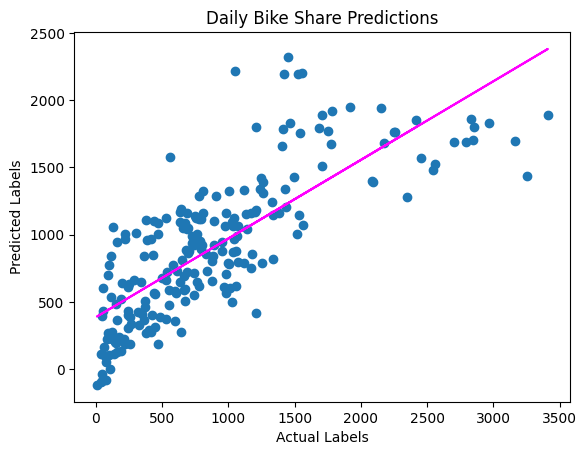

In [22]:
import matplotlib.pyplot as plt

%matplotlib inline

plt.scatter(y_test, predictions)
plt.xlabel('Actual Labels')
plt.ylabel('Predicted Labels')
plt.title('Daily Bike Share Predictions')
# overlay the regression line
z = np.polyfit(y_test, predictions, 1)
p = np.poly1d(z)
plt.plot(y_test,p(y_test), color='magenta')
plt.show()

There's a definite diagonal trend, and the intersections of the predicted and actual values are generally following the path of the trend line; but there's a fair amount of difference between the ideal function represented by the line and the results. This variance represents the *residuals* of the model - in other words, the difference between the label predicted when the model applies the coefficients it learned during training to the validation data, and the actual value of the validation label. These residuals when evaluated from the validation data indicate the expected level of *error* when the model is used with new data for which the label is unknown.

You can quantify the residuals by calculating a number of commonly used evaluation metrics. We'll focus on the following three:

- **Mean Square Error (MSE)**: The mean of the squared differences between predicted and actual values. This yields a relative metric in which the smaller the value, the better the fit of the model
- **Root Mean Square Error (RMSE)**: The square root of the MSE. This yields an absolute metric in the same unit as the label (in this case, numbers of rentals). The smaller the value, the better the model (in a simplistic sense, it represents the average number of rentals by which the predictions are wrong!)
- **Coefficient of Determination (usually known as *R-squared* or R<sup>2</sup>)**: A relative metric in which the higher the value, the better the fit of the model. In essence, this metric represents how much of the variance between predicted and actual label values the model is able to explain.

Let's use Scikit-Learn to calculate these metrics for our model, based on the predictions it generated for the validation data.

In [23]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, predictions)
print("MSE:", mse)

rmse = np.sqrt(mse)
print("RMSE:", rmse)

r2 = r2_score(y_test, predictions)
print("R2:", r2)

MSE: 199004.0328612692
RMSE: 446.09868063161673
R2: 0.6098650837934902


# explanation
- An 𝑅^2 value of 0.62 means that 62% of the variance in the target variable is explained by the mode. In most real-world applications, an 𝑅^2  between 0.5 and 0.8 is considered acceptable.

We've now seen a number of common techniques used to train predictive models for regression. In a real project, you'd likely try a few more algorithms, hyperparameters, and preprocessing transformations; but by now you should have got the general idea. Let's explore how you can use the trained model with new data.

### Use the Trained Model

First, let's save the model.

In [24]:
# save the model
import joblib

# Save the model as a pickle file
filename = 'bike-share.pkl'
joblib.dump(model, filename)

['bike-share.pkl']

Now, we can load it whenever we need it, and use it to predict labels for new data. This is often called *scoring* or *inferencing*.

In [25]:
# Load the model from the file
loaded_model = joblib.load(filename)

# Create a numpy array containing a new observation (for example tomorrow's seasonal and weather forecast information)
X_new = np.array([[False, True, 0.64, 0.59, 0.46, 0.17, False, False , False, False, True, False, False, False]])
print ('New sample: {}'.format(list(X_new[0])))

# Use the model to predict tomorrow's rentals
result = loaded_model.predict(X_new)
print('Prediction: {:.0f} rentals'.format(np.round(result[0])))

New sample: [0.0, 1.0, 0.64, 0.59, 0.46, 0.17, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0]
Prediction: 1145 rentals


C:\Users\hi\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


The model's **predict** method accepts an array of observations, so you can use it to generate multiple predictions as a batch. For example, suppose you have a weather forecast for the next five days; you could use the model to predict bike rentals for each day based on the expected weather conditions.

In [26]:
# An array of features based on five-day weather forecast
X_new = np.array([[False, True, 0.64, 0.59, 0.46, 0.17, False, False , False, False, True, False, False, False],
                 [False, True, 0.64, 0.59, 0.46, 0.17, False, False , False, False, True, False, False, True],
                 [False, True, 0.64, 0.59, 0.46, 0.17, False, False , False, False, True, False, False, False]]
)

# Use the model to predict rentals
results = loaded_model.predict(X_new)
print('5-day rental predictions:')
for prediction in results:
    print(np.round(prediction))

5-day rental predictions:
1145.0
943.0
1145.0


C:\Users\hi\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
